# 06 — Disease cost analysis

**Objective.** Compare published disease-cost totals and per-resident metrics.

**Business relevance.** Establish a transparent descriptive evidence base without merging incompatible populations or implying causality.

**Data source.** Destatis table 23631-0001  
**Period.** 2020 and 2023  
**Granularity.** Germany × year × ICD-10 group × metric  
**Units.** Million EUR and EUR per resident

Last updated: 2026-08-25

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df=pd.read_csv(DATA/'fact_disease_cost_observed.csv')
print('Shape:', df.shape)
display(df.head())
display(df.dtypes.to_frame('dtype'))
display(df.describe(include='all').T)
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))

Shape: (8, 14)


,date_key,year,diagnosis_code,diagnosis_label,metric_code,metric,value,unit,quality_flag,source_id,input_class,geography,payer_scope,denominator
0,2020,2020,E10-E14,Diabetes mellitus,KOS025,Krankheitskosten,7681.0,Mill. EUR,e,DESTATIS-23631-0001,official disease-cost estimate,Germany,all payers,national total across all payers
1,2020,2020,E10-E14,Diabetes mellitus,KOS029,Krankheitskosten je Einwohner,90.0,EUR,e,DESTATIS-23631-0001,official disease-cost estimate,Germany,all payers,resident population
2,2020,2020,E65-E68,Adipositas und sonstige Überernährung,KOS025,Krankheitskosten,977.0,Mill. EUR,e,DESTATIS-23631-0001,official disease-cost estimate,Germany,all payers,national total across all payers
3,2020,2020,E65-E68,Adipositas und sonstige Überernährung,KOS029,Krankheitskosten je Einwohner,10.0,EUR,e,DESTATIS-23631-0001,official disease-cost estimate,Germany,all payers,resident population
4,2023,2023,E10-E14,Diabetes mellitus,KOS025,Krankheitskosten,9685.0,Mill. EUR,e,DESTATIS-23631-0001,official disease-cost estimate,Germany,all payers,national total across all payers


,dtype
date_key,int64
year,int64
diagnosis_code,object
diagnosis_label,object
metric_code,object
metric,object
value,float64
unit,object
quality_flag,object
source_id,object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date_key,8.0,NaN,NaN,NaN,2021.5,1.603567,2020.0,2020.0,2021.5,2023.0,2023.0
year,8.0,NaN,NaN,NaN,2021.5,1.603567,2020.0,2020.0,2021.5,2023.0,2023.0
diagnosis_code,8,2,E10-E14,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagnosis_label,8,2,Diabetes mellitus,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metric_code,8,2,KOS025,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metric,8,2,Krankheitskosten,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value,8.0,NaN,NaN,NaN,2475.375,3896.285115,10.0,70.0,548.5,2842.75,9685.0
unit,8,2,Mill. EUR,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quality_flag,8,1,e,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_id,8,1,DESTATIS-23631-0001,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values: 0
Duplicate rows: 0


year                                                  2020             2023  \
unit                                                   EUR Mill. EUR    EUR   
diagnosis_code diagnosis_label                                                
E10-E14        Diabetes mellitus                      90.0    7681.0  120.0   
E65-E68        Adipositas und sonstige Überernährung  10.0     977.0   10.0   

year                                                            
unit                                                 Mill. EUR  
diagnosis_code diagnosis_label                                  
E10-E14        Diabetes mellitus                        9685.0  
E65-E68        Adipositas und sonstige Überernährung    1230.0

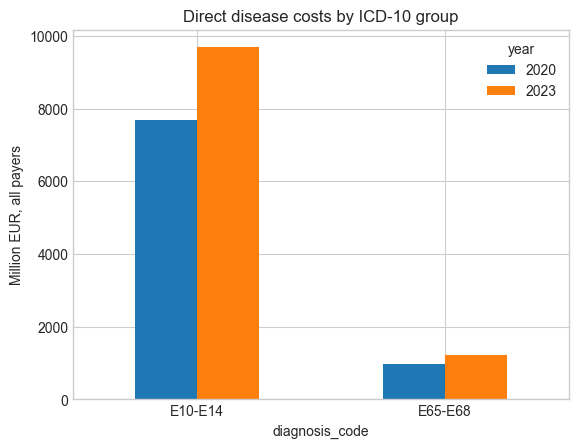

In [3]:
display(df.pivot_table(index=['diagnosis_code','diagnosis_label'],columns=['year','unit'],values='value'))
totals=df[df['unit'].eq('Mill. EUR')]
totals.pivot(index='diagnosis_code',columns='year',values='value').plot.bar(title='Direct disease costs by ICD-10 group'); plt.ylabel('Million EUR, all payers'); plt.xticks(rotation=0); plt.show()

## Interpretation

ICD-10 E10–E14 represents diabetes mellitus as a diagnostic group, including type 1, type 2 and other forms of diabetes. Its 2023 total was EUR 9,685 million. E65–E68 covers obesity and other hyperalimentation diagnoses. Total and per-resident metrics remain separate; neither is a GLP-1 cost.

## Limitations, outputs and conclusion

The analysis preserves source periods, units and denominators; it does not impute, interpolate or claim causality. Outputs are the displayed summary tables and Matplotlib figures. The conclusion is descriptive and should be read with the source-specific limitations above.

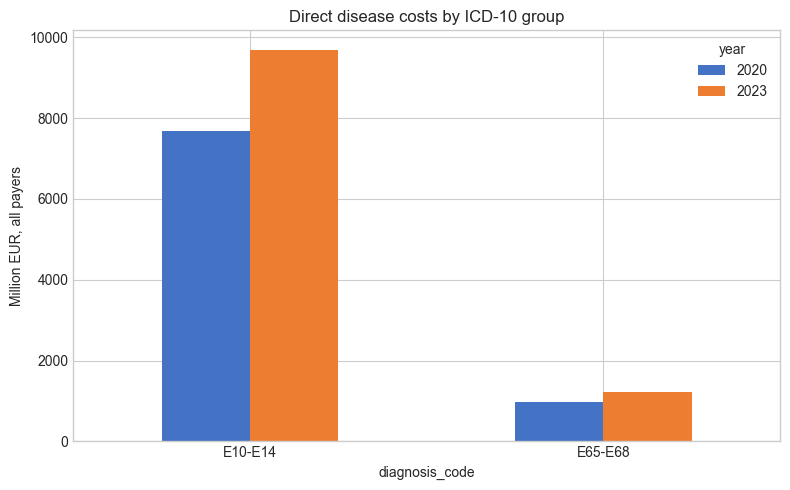

In [4]:
IMAGE_DIR = ROOT / 'images' / 'disease_costs'; IMAGE_DIR.mkdir(parents=True, exist_ok=True)
totals=df[df['unit'].eq('Mill. EUR')]
ax=totals.pivot(index='diagnosis_code',columns='year',values='value').plot.bar(title='Direct disease costs by ICD-10 group',figsize=(8,5),color=['#4472C4','#ED7D31'])
ax.set_ylabel('Million EUR, all payers'); plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(IMAGE_DIR/'disease_costs_comparison.png',dpi=180); plt.show()
